# Assignment 3: Transformer is All You Need
**Dataset:** Shakespearean Text (ShakespeareTinyCorpus.txt)

## 1. Introduction
This notebook explores a lightweight Transformer-based language model for next-token prediction using a subset of Shakespearean text. The project implements an end-to-end flow that includes training a Byte Pair Encoding (BPE) tokenizer, constructing a custom dataset of token sequences, and building a small autoregressive Transformer from scratch using PyTorch.

The model leverages key architectural components such as positional encoding causal self-attention, RMS normalization, and feedforward networks to learn contextual relationships between tokens. Training and evaluation are performed on a train-validation split, with performance measured using cross-entropy loss and perplexity.

Finally, the notebook visualizes training dynamics and interprets model behavior through attention heatmaps, providing insight into how the Transformer attends to different parts of the input when generating predictions.

## 2. Data Preparation
We load the UCI dataset. Standard cleaning, feature engineering, splitting (70/15/15), and scaling (for MLP).

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request as request
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, average_precision_score
from sklearn.metrics import log_loss
from xgboost import XGBClassifier, plot_importance

# Reading data and handling missing values and inconsistent types
#   The Bank Marketing dataset uses ";" as a delimiter
#   Categorical 'unknown' values are handled via One-Hot Encoding later
url = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment2/main/bank-full.csv"
filename = "bank-full.csv"
request.urlretrieve(url, filename)
df = pd.read_csv(filename, sep=';')

# Optional Feature Construction
#   Constructing a 'balance_age_ratio' feature to capture financial status relative to age
df['balance_age_ratio'] = df['balance'] / (df['age'] + 1)

# Data Leakage Prevention Measure
#   As explained in the bank-names.txt file, 'duration' is only known after the call
#   Dropping it here to ensure the model is truly predictive for future campaigns based on demographics and campaign freatures
df = df.drop(columns=['duration'])

X = df.drop(columns=['y'])
# Binarizing target variable
y = df['y'].map({'yes': 1, 'no': 0})

# Split data into train / validation / test sets (70 / 15 / 15)
#   Stratified split ensures the class imbalance (~11% yes) is maintained across sets.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Feature Scaling and Encoding (Mandatory for MLP)
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# DISCUSSION: Why is scaling necessary for MLP but not for GBDT?
#   MLP (Neural Networks) are sensitive to feature scaling because they use Gradient Descent
#   Unscaled features cause the loss landscape to be skewed, making convergence difficult
#   GBDT (Tree-based models) split based on feature thresholds/rank, making them scale-invariant
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# No Data Leakage Insured: Fitted ONLY on training set
#   Imputation, scaling, and encoding parameters are learned from X_train ONLY
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

print(f"Preprocessing Complete. Training features: {X_train_enc.shape[1]}")

Preprocessing Complete. Training features: 51


## 3. Gradient Boosted Tree (GBDT)
Training an XGBClassifier

Starting Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters found: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}


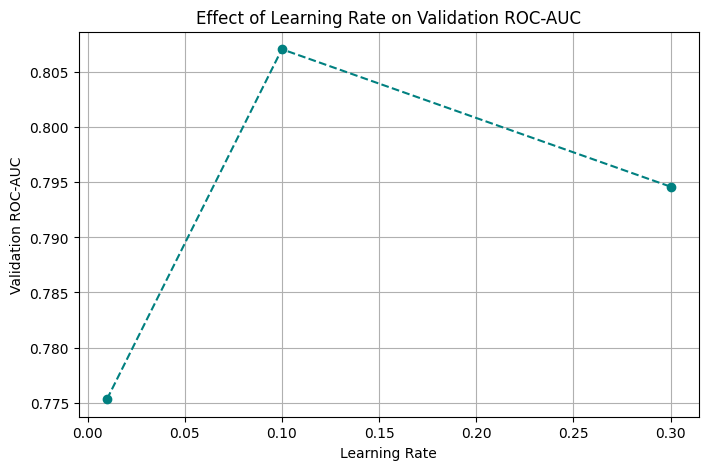

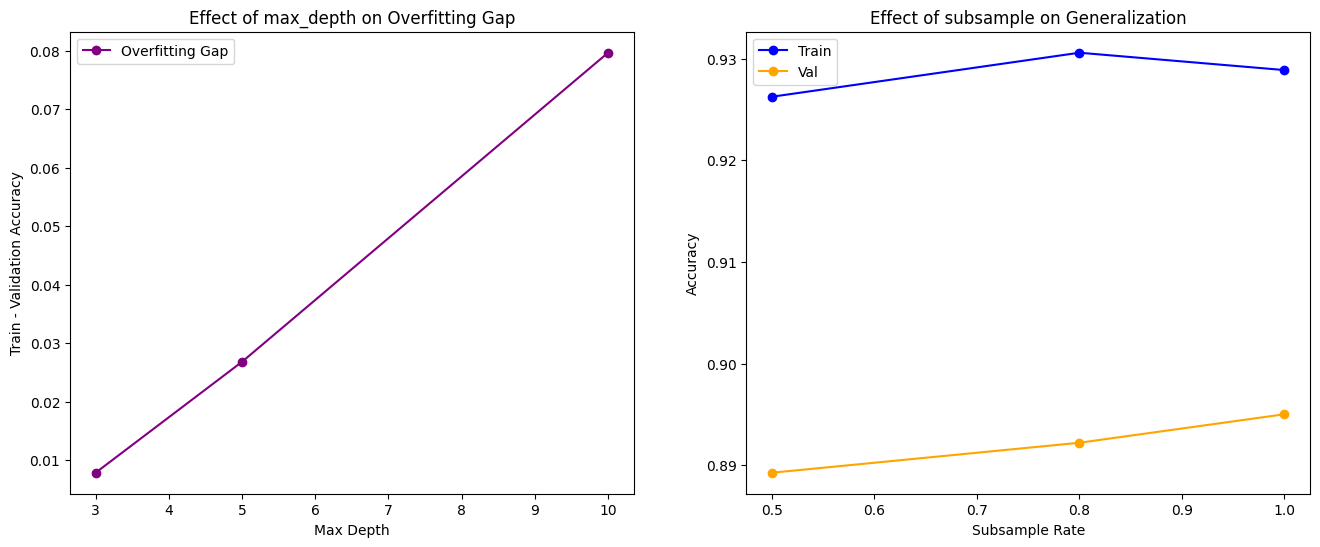

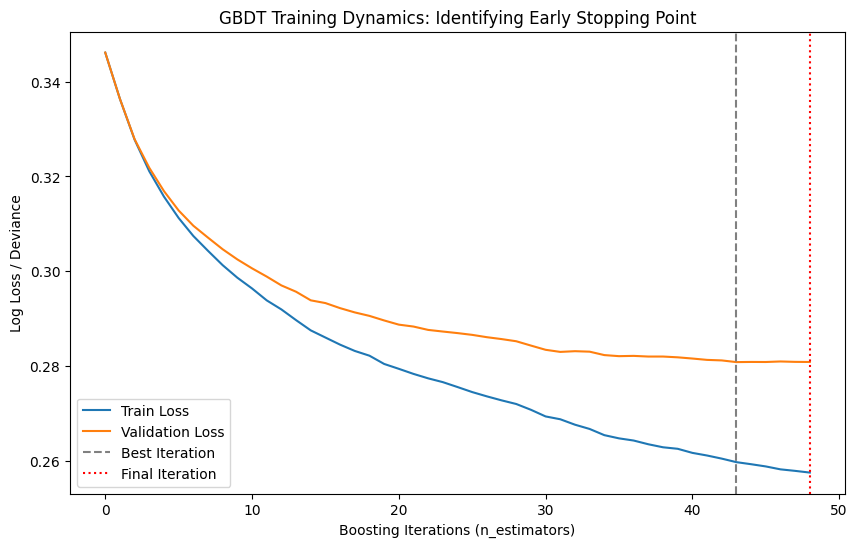

<Figure size 1000x800 with 0 Axes>

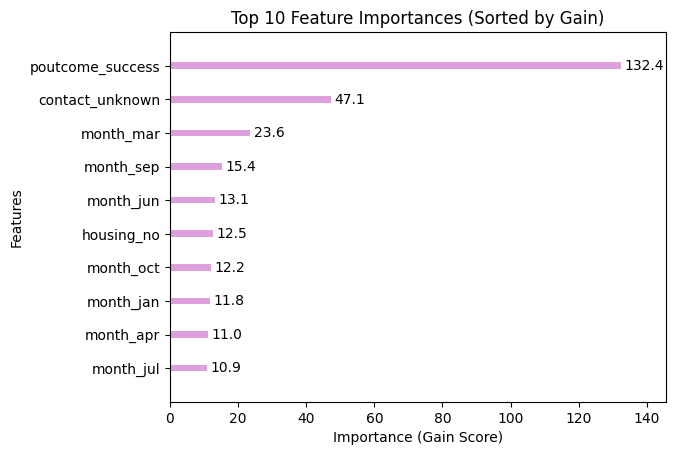

In [ ]:
# Using RandomizedSearchCV to hypertune parameters to efficiently find a strong baseline
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search...")
random_search.fit(X_train_enc, y_train)
print(f"Best Parameters found: {random_search.best_params_}")
best_params = random_search.best_params_.copy()

# Effect of Learning Rate Comparison
#   Comparing results for at least 3 values (0.01, 0.1, 0.3)
learning_rates = [0.01, 0.1, 0.3]
lr_results = []

for lr in learning_rates:
    # Training separate models to observe the impact of the 'Step Size' shrinkage
    temp_xgb = XGBClassifier(n_estimators=100, learning_rate=lr, random_state=42)
    temp_xgb.fit(X_train_enc, y_train)
    # Using ROC-AUC to evaluate ranking performance across different rates
    score = roc_auc_score(y_val, temp_xgb.predict_proba(X_val_enc)[:, 1])
    lr_results.append(score)

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, lr_results, marker='o', color='teal', linestyle='--')
plt.title('Effect of Learning Rate on Validation ROC-AUC')
plt.xlabel('Learning Rate')
plt.ylabel('Validation ROC-AUC')
plt.grid(True)
plt.show()

# Exploring Complexity and Overfitting from max_depth & subsample Parameters
depths = [3, 5, 10]
sub_rates = [0.5, 0.8, 1.0]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Testing Tree Depth (Capacity to fit complex patterns)
train_depth_scores = []
val_depth_scores = []

for d in depths:
    m = XGBClassifier(n_estimators=100, max_depth=d, random_state=42)
    m.fit(X_train_enc, y_train)
    train_depth_scores.append(m.score(X_train_enc, y_train))
    val_depth_scores.append(m.score(X_val_enc, y_val))

gap_scores = np.array(train_depth_scores) - np.array(val_depth_scores)

ax[0].plot(depths, gap_scores, 'o-', color='purple', label='Overfitting Gap')
ax[0].set_title('Effect of max_depth on Overfitting Gap')
ax[0].set_xlabel('Max Depth')
ax[0].set_ylabel('Train - Validation Accuracy')
ax[0].legend()

# Testing Subsample (Stochastic Gradient Boosting to improve generalization)
train_scores = []
val_scores = []

for s in sub_rates:
    m = XGBClassifier(n_estimators=100, subsample=s, random_state=42)
    m.fit(X_train_enc, y_train)
    train_scores.append(m.score(X_train_enc, y_train))
    val_scores.append(m.score(X_val_enc, y_val))

ax[1].plot(sub_rates, train_scores, 'o-', color='blue', label='Train')
ax[1].plot(sub_rates, val_scores, 'o-', color='orange', label='Val')
ax[1].set_title('Effect of subsample on Generalization')
ax[1].set_xlabel('Subsample Rate')
ax[1].set_ylabel('Accuracy')
ax[1].legend()


# Training vs. Validation Loss (Monitoring Convergence)
#   Using n_estimators and a validation set to monitor for overfitting
#   Also exploring reg_alpha/reg_lambda
model_xgb = XGBClassifier(**best_params, random_state=42, early_stopping_rounds=5)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_train_enc, y_train), (X_val_enc, y_val)], verbose=False)

# Extracting evaluation results for visualization
results = model_xgb.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')
plt.title('GBDT Training Dynamics: Identifying Early Stopping Point')
plt.xlabel('Boosting Iterations (n_estimators)')
plt.ylabel('Log Loss / Deviance')
plt.axvline(model_xgb.best_iteration, linestyle='--', color='gray', label='Best Iteration')
plt.axvline(epochs-1, linestyle=':', color='red', label='Final Iteration')
plt.legend()
plt.show()

# Feature Importance
#   Visualizing feature importance (using built-in plot_importance)
feat_names = [name.split('__')[-1] for name in preprocessor.get_feature_names_out()]
model_xgb.get_booster().feature_names = feat_names

plt.figure(figsize=(10, 8))
ax = plot_importance(model_xgb, importance_type='gain', max_num_features=10, color='plum', grid=False)

for text in ax.texts:
    val = float(text.get_text())
    text.set_text(f'{val:.1f}')

plt.title('Top 10 Feature Importances (Sorted by Gain)')
plt.xlabel('Importance (Gain Score)')
plt.show()

## 4. Multi-Layer Perceptron (MLP)
Train an MLPClassifier

Starting MLP Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best MLP Parameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'activation': 'relu'}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


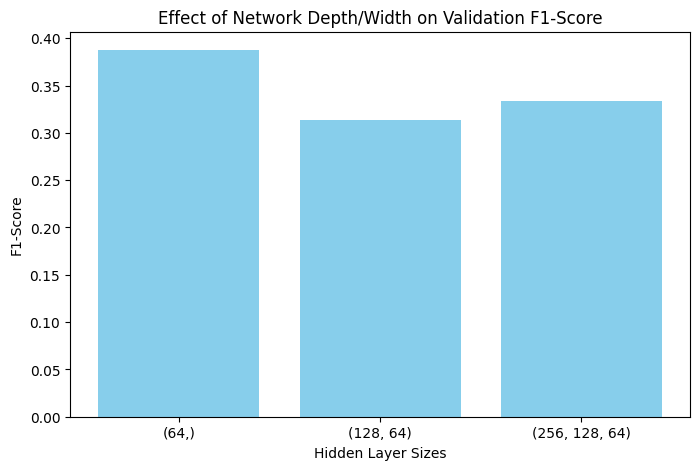

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


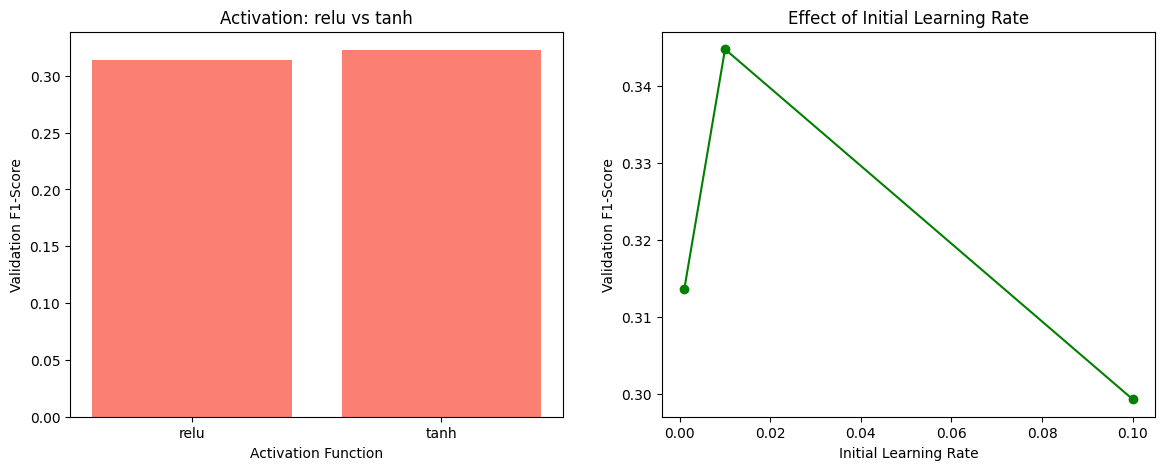

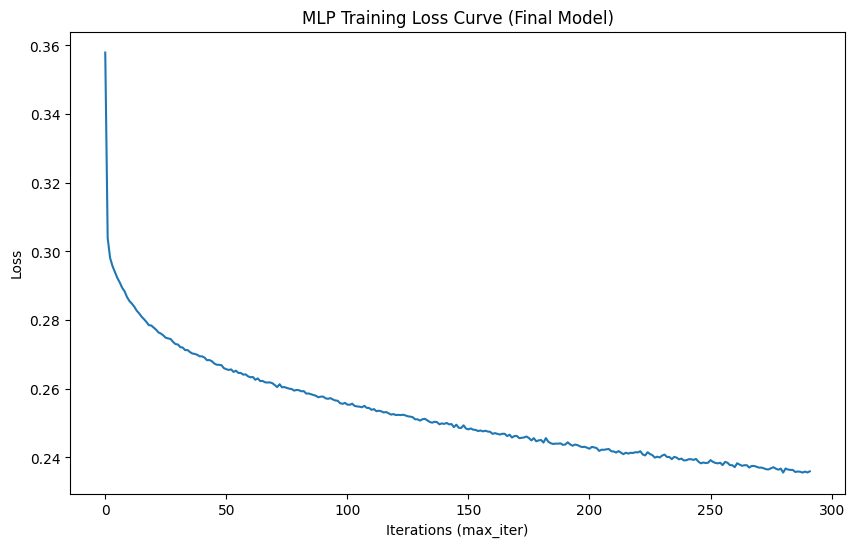

In [ ]:
# Using RandomizedSearchCV to hypertune parameters to efficiently find a strong baseline
param_dist_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

random_search_mlp = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=param_dist_mlp,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting MLP Randomized Search...")
random_search_mlp.fit(X_train_enc, y_train)
print("Best MLP Parameters:", random_search_mlp.best_params_)
best_params_mlp = random_search_mlp.best_params_.copy()

# Sensitivity to Feature Scaling
#   As established in Step 1, we are using StandardScaler

# Effect of Architecture (Depth/Width) on Performance
#   Explore (64,), (128, 64), (256, 128, 64)
archs = [(64,), (128, 64), (256, 128, 64)]
arch_scores = []

for arch in archs:
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=300, random_state=42)
    m.fit(X_train_enc, y_train)
    # Using F1-score to evaluate performance on the imbalanced validation set
    arch_scores.append(f1_score(y_val, m.predict(X_val_enc)))

plt.figure(figsize=(8, 5))
plt.bar([str(a) for a in archs], arch_scores, color='skyblue')
plt.title('Effect of Network Depth/Width on Validation F1-Score')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('F1-Score')
plt.show()


# Effect of Activation (relu vs tanh)
activations = ['relu', 'tanh']
act_scores = []

for act in activations:
    m = MLPClassifier(hidden_layer_sizes=(128, 64), activation=act, max_iter=300, random_state=42)
    m.fit(X_train_enc, y_train)
    act_scores.append(f1_score(y_val, m.predict(X_val_enc)))


# Effect of learning_rate_init (0.001, 0.01, 0.1)
lrs = [0.001, 0.01, 0.1]
lr_scores = []

for lr in lrs:
    m = MLPClassifier(hidden_layer_sizes=(128, 64), learning_rate_init=lr, max_iter=300, random_state=42)
    m.fit(X_train_enc, y_train)
    lr_scores.append(f1_score(y_val, m.predict(X_val_enc)))

# Visualizing Activation and Learning Rate effects
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(activations, act_scores, color='salmon')
ax[0].set_title('Activation: relu vs tanh')
ax[0].set_xlabel('Activation Function')
ax[0].set_ylabel('Validation F1-Score')
ax[1].plot(lrs, lr_scores, marker='o', color='green')
ax[1].set_title('Effect of Initial Learning Rate')
ax[1].set_xlabel('Initial Learning Rate')
ax[1].set_ylabel('Validation F1-Score')
plt.show()


# Final Model Training and Loss Curve
#   Visualizing training loss curve using loss_curve_
#   We use max_iter=1000 to ensure convergence
mlp_final = MLPClassifier(**best_params_mlp, max_iter=1000, random_state=42)
mlp_final.fit(X_train_enc, y_train)

plt.figure(figsize=(10, 6))
plt.plot(mlp_final.loss_curve_)
plt.title('MLP Training Loss Curve (Final Model)')
plt.xlabel('Iterations (max_iter)')
plt.ylabel('Loss')
plt.show()

## 5. Comparison Table
Using the same dataset and the same train/test split, we compare both model approaches

Measuring training times...
FINAL MODEL COMPARISON SUMMARY (TEST SET)


,Accuracy,Precision,Recall,F1-Score,AUC-PR,Training Time (s)
Model,,,,,,
GBDT (XGBoost),0.8969,0.6728,0.2308,0.3437,0.4663,3.5124
MLP (Neural Net),0.8871,0.5295,0.3052,0.3872,0.3746,73.0662


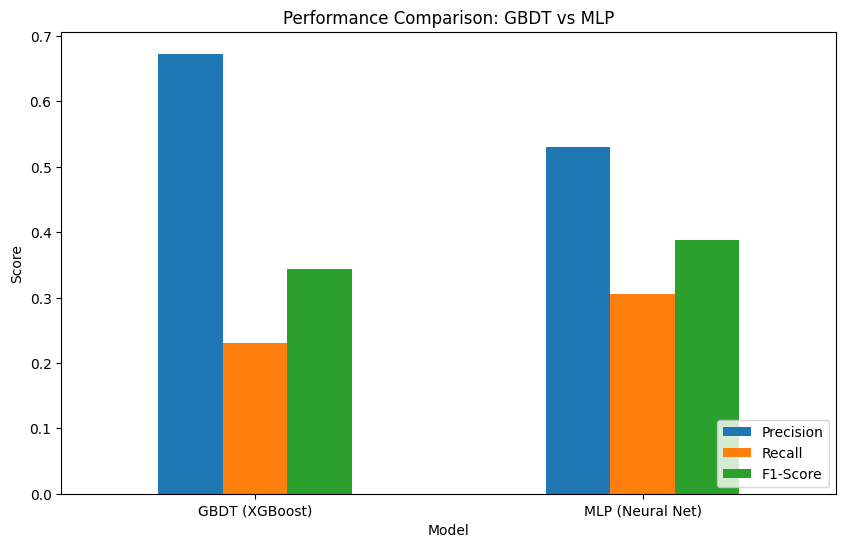

'\nMLP is relatively more sensitive to hyperparameter choices. A slightly too-high\nlearning rate or a poor choice of activation function can cause Dying ReLUs or\nexploding gradients, making the model fail to converge entirely (as seen in the\nConvergenceWarnings during some earlier tests conducted with lower iterations).\n\nGBDT is more Plug-and-Play. While tuning max_depth and learning_rate helps, a GBDT\nwith default parameters will often outperform a poorly tuned MLP. GBDTs are generally\nmore stable across different datasets.\n'

In [ ]:
print("Measuring training times...")

start_gbdt = time.time()
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_val_enc, y_val)], verbose=False)
train_time_gbdt = time.time() - start_gbdt

start_mlp = time.time()
mlp_final.fit(X_train_enc, y_train)
train_time_mlp = time.time() - start_mlp

# Get Metrics Function
def get_metrics(model, X, y, name, train_time):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'AUC-PR': average_precision_score(y, y_proba),
        'Training Time (s)': train_time
    }

gbdt_results = get_metrics(model_xgb, X_test_enc, y_test, "GBDT (XGBoost)", train_time_gbdt)
mlp_results = get_metrics(mlp_final, X_test_enc, y_test, "MLP (Neural Net)", train_time_mlp)

# Create Comparison Table
comparison_df = pd.DataFrame([gbdt_results, mlp_results]).set_index('Model')

print("FINAL MODEL COMPARISON SUMMARY (TEST SET)")
display(comparison_df.round(4))

# Final Comparison Plot
comparison_df[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison: GBDT vs MLP')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Discussion Points
# When would you prefer GBDT over MLP, and vice versa?
"""
GBDT would be preferred when Working with tabular data (spreadsheets, SQL tables).
GBDTs are notoriously dominant in this domain. They are faster to train, require
less data to reach high accuracy, and are relatively robust to outliers.

MLP would be preferred when you have unstructured data (images, audio, text) or
when you need to perform Online Learning (updating the model one sample at a time),
which MLPs handle more natively than standard GBDT implementations.
"""
# How does interpretability differ? (GBDT has feature importance; MLP is a black box)
"""
GBDTs offer high interpretability via Feature Importance. We can see exactly which
variables (e.g., poutcome_success) are driving the most splits in the trees. This is
essential for business stakeholders who need to know why a customer is being targeted.

MLPs gennerally are viewed as "Black Boxes". While we can visualize weights, the
millions of non-linear interactions between neurons make it nearly impossible to
explain a specific prediction in a way that we as humans can intuitively understand.
"""
# How does each model handle categorical features and missing values?
"""
GBDT model has modern libraries like XGBoost that can handle categorical features
and missing values natively (using sparsity-aware splitting). Even if they aren't
handled natively, trees are robust to the scale of encoded variables.

MLP model requires relatively more extensive preprocessing. Categorical features
must be encoded (One-Hot or Embeddings), and missing values must be imputed.
Due to MLPs using Gradient Descent, they are also highly sensitive to the scale
of these features, requiring Standardization.
"""
# Which model is more sensitive to hyperparameter choices?
"""
MLP is relatively more sensitive to hyperparameter choices. A slightly too-high
learning rate or a poor choice of activation function can cause Dying ReLUs or
exploding gradients, making the model fail to converge entirely (as seen in the
ConvergenceWarnings during some earlier tests conducted with lower iterations).

GBDT is more Plug-and-Play. While tuning max_depth and learning_rate helps, a GBDT
with default parameters will often outperform a poorly tuned MLP. GBDTs are generally
more stable across different datasets.
"""